In [1]:
# loads numpy and matplotlib
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import torch # WE WILL BE USING PYTORCH THIS TIME, 
             # IT IS MORE ADVANCED THAN KERAS BUT EXTREMELY POPULAR!
             # MOST OF THE CODE HERE IS READY TO GO JUST TRY TO UNDERSTAND IT!

In [3]:
#
# CHECK IF THE GPU IS AVAILABLE ON CHIMERA21
#
if torch.cuda.is_available():
    device = 'cuda'
    print(torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print('GPU not available, using CPU!')

NVIDIA H200 MIG 1g.35gb


## 1. Data Processing. (10 points)

In [4]:
### DOWNLOAD THE DATA
!wget https://cs666.org/data/mito.npz

--2026-04-27 16:59:12--  https://cs666.org/data/mito.npz
Resolving cs666.org (cs666.org)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to cs666.org (cs666.org)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 37610178 (36M) [application/octet-stream]
Saving to: ‘mito.npz.4’

mito.npz.4          100%[===================>]  35.87M  91.6MB/s    in 0.4s    

2026-04-27 16:59:13 (91.6 MB/s) - ‘mito.npz.4’ saved [37610178/37610178]



In [5]:
# The data includes images and manually segmented masks.
loaded = np.load('mito.npz')
images = loaded['arr_0'][0]
masks = loaded['arr_0'][1]

In [6]:
# PROCESS THE IMAGES
images = (images - images.min()) / (images.max() - images.min())
masks = masks.astype(bool).astype(float)

In [7]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER
#It loads images and their corresponding masks from a .npz file, then normalizes the image pixel values to the range [0,1]. 
#It also converts the masks into binary format, where all non-zero values become 1.0 and zero values become 0.0.

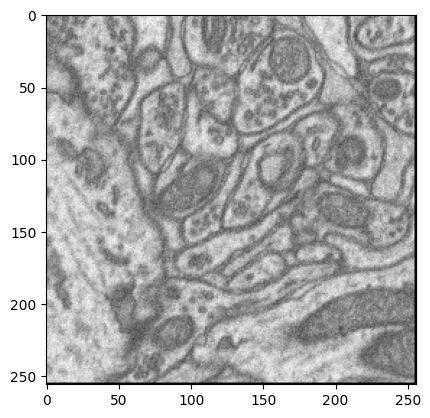

In [8]:
imshow(images[0], cmap='gray')

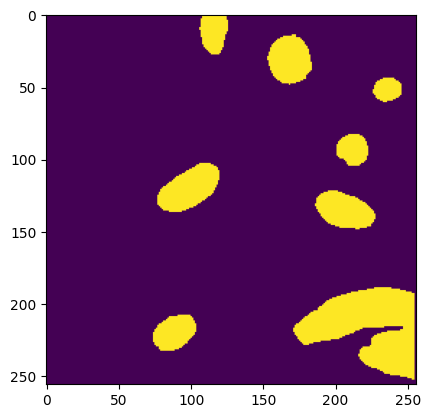

In [9]:
imshow(masks[0])

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [11]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER
#It splits the dataset into training (70%), and a temporary set (30%), 
#then splits that temporary set evenly into validation (15%) and test (15%) sets. 
#The random_state=42 ensures the split is reproducible every time you run it.

## 2. Make the Data Pytorch-ready! (10 points)

In [12]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [13]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([])

In [14]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER
#It defines data augmentation pipelines using Albumentations. 
#The training pipeline randomly applies flips and 90° rotations to increase data variety(i.e., Horizontal,Vertical,RandomRotate90), 
#while the validation pipeline applies no transformations so evaluation uses the original images.

In [15]:
class MitoDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # add channel dimension: (H, W) -> (1, H, W)
        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [16]:
train_dataset = MitoDataset(X_train, y_train, transform=train_transform)
val_dataset = MitoDataset(X_val, y_val, transform=val_transform)
test_dataset = MitoDataset(X_test, y_test, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [17]:
# TODO: What does the above code do?
# TODO: YOUR ANSWER
#It defines a custom PyTorch dataset class that loads image–mask pairs, applies optional augmentations, adds a channel dimension, and converts them into tensors.
#It creates dataset objects for train, validation, and test data (applying augmentation only to training), and then wraps them in DataLoaders that load data in batches of 16. 
#The training loader shuffles the data for better learning, while validation and test loaders keep the order fixed for consistent evaluation.

## 3. Configure the Classifier! (30 points)

In [18]:
#
# SETUP U-NET
#
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18", 
    encoder_weights=None,
    in_channels=1,
    classes=1
).to(device)

In [19]:
# DICE LOSS FUNCTION
dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [20]:
# DICE METRIC
def dice_score(pred, target, threshold=0.5, eps=1e-7):
    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

In [21]:
# SINGLE EPOCH, PYTORCH IS A BIT MORE COMPLEX HERE..
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_dice = 0.0

    for images_batch, masks_batch in loader:
        images_batch = images_batch.to(device)
        masks_batch = masks_batch.to(device)

        with torch.set_grad_enabled(training):
            preds = model(images_batch)
            loss = loss_fn(preds, masks_batch)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(preds, masks_batch)

    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

## 4. Train the U-Net! (20 points)

In [22]:
#
# TRAINING LOOP
#
num_epochs = 10

train_losses, val_losses = [], []
train_dices, val_dices = [], []

best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_dices.append(train_dice)
    val_dices.append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

print("Best val dice:", best_val_dice)

Epoch 1/10 | train_loss=0.5554, train_dice=0.4772 | val_loss=0.5874, val_dice=0.0029
Epoch 2/10 | train_loss=0.2960, train_dice=0.8067 | val_loss=0.2312, val_dice=0.8035
Epoch 3/10 | train_loss=0.1561, train_dice=0.8554 | val_loss=0.2355, val_dice=0.7278
Epoch 4/10 | train_loss=0.1048, train_dice=0.8804 | val_loss=0.1008, val_dice=0.8757
Epoch 5/10 | train_loss=0.0768, train_dice=0.9092 | val_loss=0.0821, val_dice=0.8889
Epoch 6/10 | train_loss=0.0645, train_dice=0.9203 | val_loss=0.0625, val_dice=0.9207
Epoch 7/10 | train_loss=0.0581, train_dice=0.9260 | val_loss=0.0691, val_dice=0.9065
Epoch 8/10 | train_loss=0.0533, train_dice=0.9311 | val_loss=0.0617, val_dice=0.9139
Epoch 9/10 | train_loss=0.0485, train_dice=0.9363 | val_loss=0.0446, val_dice=0.9412
Epoch 10/10 | train_loss=0.0502, train_dice=0.9344 | val_loss=0.0624, val_dice=0.9107
Best val dice: 0.9412170733724322


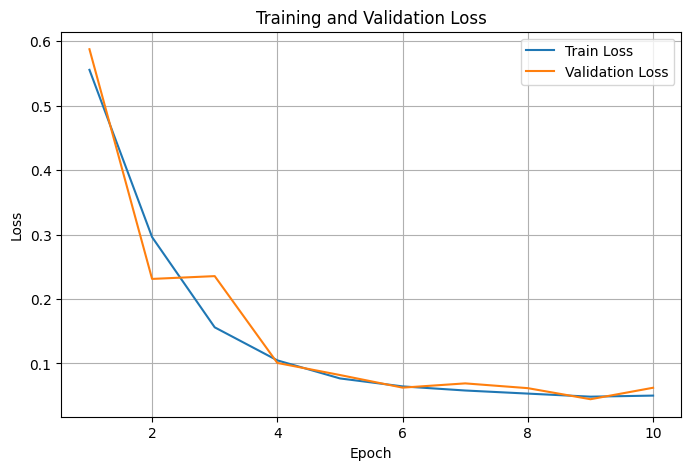

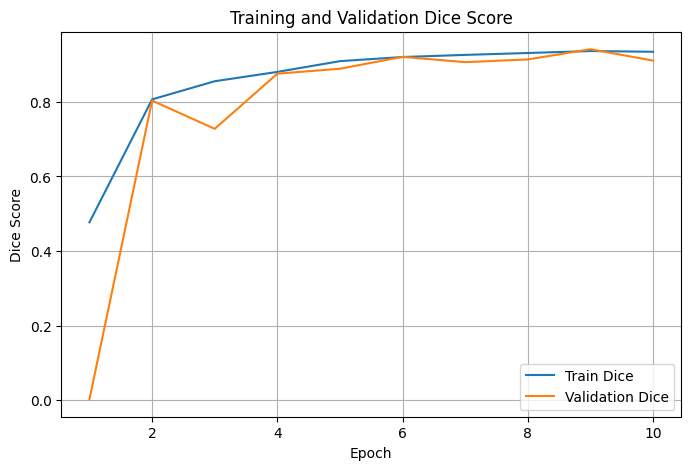

In [23]:
# TODO: Plot the loss and dice curves!
# TODO: YOUR CODE

epochs = range(1, num_epochs + 1)

# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot Dice score curves
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_dices, label="Train Dice")
plt.plot(epochs, val_dices, label="Validation Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Training and Validation Dice Score")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# TODO: Do these plots look good?
# TODO: YOUR ANSWER

#Yes, the plots look good, training and validation loss decrease smoothly while Dice scores increase and stay close, indicating stable learning and good generalization. 
#Minor observation include a very low initial validation Dice score which is normal during validation.

## 5. Testing the U-Net. (20 points)

In [25]:
# EVALUATE THE MODEL ON THE TEST DATA
model.load_state_dict(torch.load("best_mito_model.pth", map_location=device))
test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Test loss:", round(test_loss, 4))
print("Test dice:", round(test_dice, 4))

Test loss: 0.0423
Test dice: 0.9449


In [26]:
# Scores are good but let's do some Detective Work to see if
# the classifier actually works well!

# RUN PREDICTIONS
model.eval()

images_batch, masks_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds = model(images_batch)
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

images_batch = images_batch.cpu().numpy()
masks_batch = masks_batch.numpy()
preds = preds.cpu().numpy()

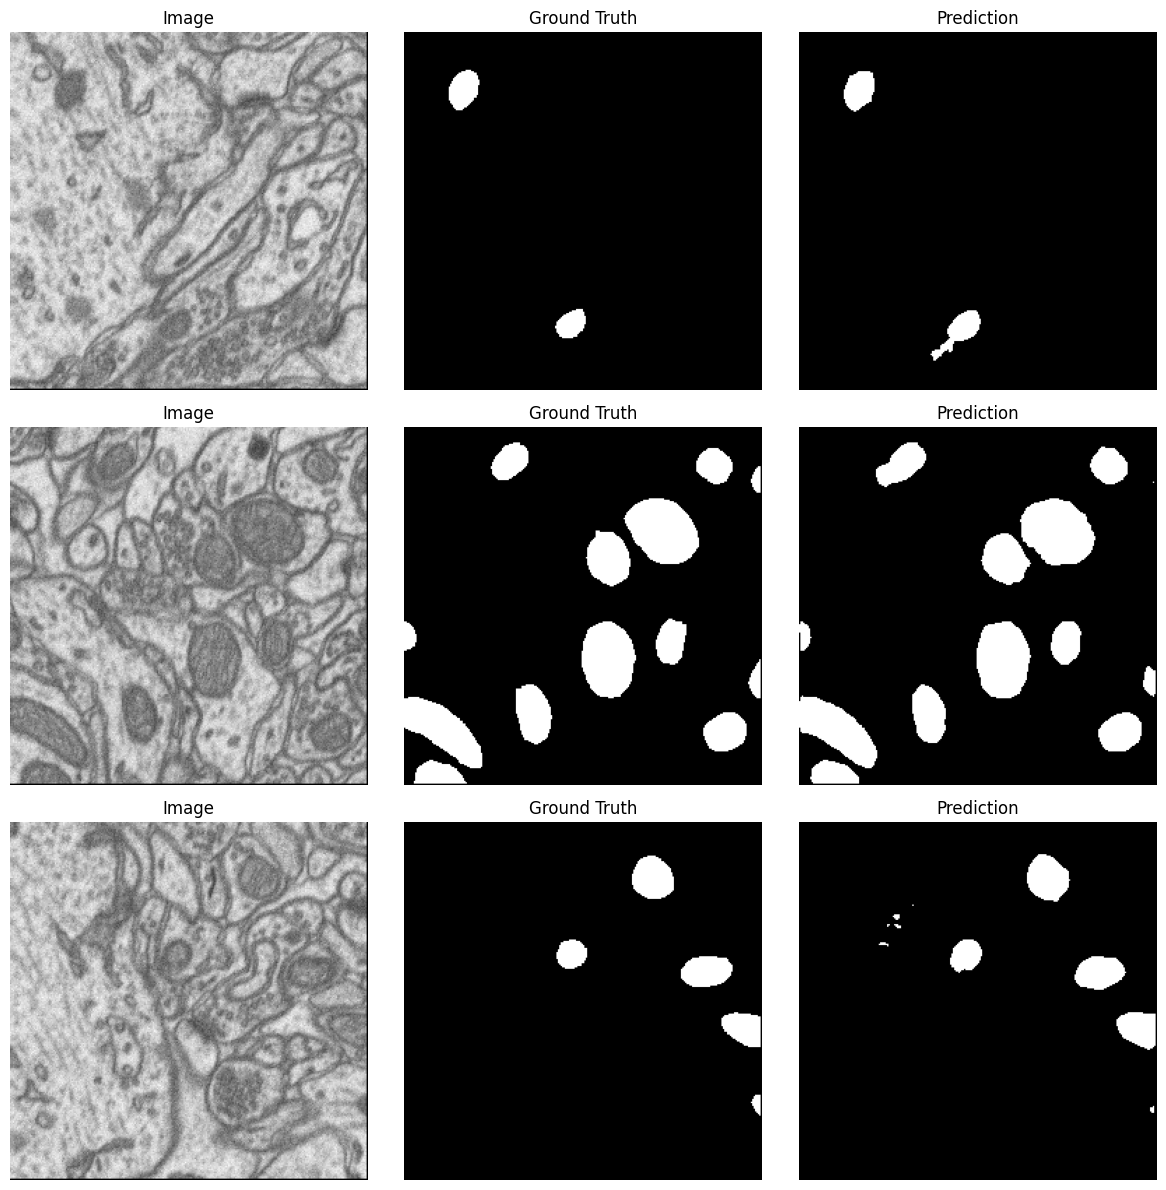

In [27]:
# SHOW EXAMPLE PREDICTIONS OF THE TEST SET
n = 3

plt.figure(figsize=(12, 4 * n))

for i in range(n):
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(images_batch[i, 0], cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(masks_batch[i, 0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(preds[i, 0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Interpretation. (10 points)

In [28]:
# TODO: Do you think the classifier works well?
# TODO: YOUR ANSWER
#Yes, the classifier works well—the predictions closely match the ground truth in shape, size, and location, showing strong segmentation performance. 
#Minor observations include slightly rough edges and tiny missed or extra regions in some predictions, but overall the model captures the objects accurately.

## Bonus: Improve the results. (33 points)

In [29]:
# Try to get better performance and show an improved Dice score on the test set!
# TODO: YOUR CODE!
# Use pretrained encoder for better performance
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
).to(device)

dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss = nn.BCEWithLogitsLoss()

def loss_fn(pred, target):
    return 0.4 * bce_loss(pred, target) + 0.6 * dice_loss(pred, target)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 30
best_val_dice = 0.0

for epoch in range(num_epochs):
    train_loss, train_dice = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_dice = run_epoch(model, val_loader, optimizer=None)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_mito_model_improved.pth")

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f}, train_dice={train_dice:.4f} | "
        f"val_loss={val_loss:.4f}, val_dice={val_dice:.4f}"
    )

# Load best model and evaluate on test set
model.load_state_dict(torch.load("best_mito_model_improved.pth"))

test_loss, test_dice = run_epoch(model, test_loader, optimizer=None)

print("Improved Test Dice Score:", test_dice)

Epoch 1/30 | train_loss=0.7395, train_dice=0.2349 | val_loss=0.7287, val_dice=0.2698
Epoch 2/30 | train_loss=0.6116, train_dice=0.5636 | val_loss=0.6412, val_dice=0.4630
Epoch 3/30 | train_loss=0.5163, train_dice=0.7822 | val_loss=0.4646, val_dice=0.8274
Epoch 4/30 | train_loss=0.4428, train_dice=0.8382 | val_loss=0.4115, val_dice=0.8449
Epoch 5/30 | train_loss=0.3895, train_dice=0.8754 | val_loss=0.3659, val_dice=0.8862
Epoch 6/30 | train_loss=0.3511, train_dice=0.8888 | val_loss=0.3252, val_dice=0.8872
Epoch 7/30 | train_loss=0.3131, train_dice=0.9046 | val_loss=0.2947, val_dice=0.9177
Epoch 8/30 | train_loss=0.2814, train_dice=0.9127 | val_loss=0.2553, val_dice=0.9255
Epoch 9/30 | train_loss=0.2485, train_dice=0.9242 | val_loss=0.2288, val_dice=0.9404
Epoch 10/30 | train_loss=0.2211, train_dice=0.9312 | val_loss=0.2009, val_dice=0.9335
Epoch 11/30 | train_loss=0.2003, train_dice=0.9319 | val_loss=0.1785, val_dice=0.9407
Epoch 12/30 | train_loss=0.1777, train_dice=0.9397 | val_loss=0

In [33]:
# In the paper they have given IOU = 0.900 which is converted to Dice Score of 0.947 (i.e., Dice = 2*(IOU)/(1+IOU))
#Now we got the improved Test Dice Score of 0.965.

#I improved the model by using a ResNet34 encoder instead of ResNet18, initializing it with ImageNet pretrained weights, and training the network for 30 epochs.

In [34]:
#
# You made it!!
#
#                 _ ___                /^^\ /^\  /^^\_
#     _          _@)@) \            ,,/ '` ~ `'~~ ', `\.
#   _/o\_ _ _ _/~`.`...'~\        ./~~..,'`','',.,' '  ~:
#  / `,'.~,~.~  .   , . , ~|,   ,/ .,' , ,. .. ,,.   `,  ~\_
# ( ' _' _ '_` _  '  .    , `\_/ .' ..' '  `  `   `..  `,   \_
#  ~V~ V~ V~ V~ ~\ `   ' .  '    , ' .,.,''`.,.''`.,.``. ',   \_
#   _/\ /\ /\ /\_/, . ' ,   `_/~\_ .' .,. ,, , _/~\_ `. `. '.,  \_
#  < ~ ~ '~`'~'`, .,  .   `_: ::: \_ '      `_/ ::: \_ `.,' . ',  \_
#   \ ' `_  '`_    _    ',/ _::_::_ \ _    _/ _::_::_ \   `.,'.,`., \-,-,-,_,_,
#    `'~~ `'~~ `'~~ `'~~  \(_)(_)(_)/  `~~' \(_)(_)(_)/ ~'`\_.._,._,'_;_;_;_;_;
#